<a href="https://colab.research.google.com/github/Soumyajitnath52/Cloud-Cost-Analyzer-Predictor/blob/main/Cloud_Cost_Analyzer_%26_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== COLAB CLOUD COST ANALYZER PROJECT =====
# Install dependencies
!pip install pandas numpy scikit-learn fastapi uvicorn python-multipart gcsfs google-cloud-aiplatform

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Cloud Cost Analyzer Project Started!")

🚀 Cloud Cost Analyzer Project Started!


In [2]:
# Create realistic cloud billing dataset
np.random.seed(42)
n_samples = 10000

data = {
    'timestamp': pd.date_range('2023-01-01', periods=n_samples, freq='H'),
    'vm_count': np.random.randint(1, 50, n_samples),
    'storage_gb': np.random.uniform(100, 5000, n_samples),
    'network_gb': np.random.uniform(10, 1000, n_samples),
    'cpu_utilization': np.random.uniform(0.1, 0.9, n_samples),
    'region': np.random.choice(['us-central1', 'europe-west1', 'asia-east1'], n_samples),
    'service': np.random.choice(['Compute', 'Storage', 'Network', 'Database'], n_samples),
    'cost_usd': 0  # Will calculate
}

df = pd.DataFrame(data)

# Realistic cost calculation
def calculate_cost(row):
    base_cost = row['vm_count'] * 0.05  # VM cost
    storage_cost = row['storage_gb'] * 0.023  # Storage
    network_cost = row['network_gb'] * 0.12  # Network
    return base_cost + storage_cost + network_cost + np.random.uniform(0, 50)

df['cost_usd'] = df.apply(calculate_cost, axis=1)
df['cost_per_vm'] = df['cost_usd'] / (df['vm_count'] + 1)

print("📊 Dataset created:", df.shape)
df.head()

/tmp/ipykernel_4586/1406506509.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range('2023-01-01', periods=n_samples, freq='H'),


📊 Dataset created: (10000, 9)


,timestamp,vm_count,storage_gb,network_gb,cpu_utilization,region,service,cost_usd,cost_per_vm
0,2023-01-01 00:00:00,39,1543.556331,697.166457,0.887234,asia-east1,Database,130.780903,3.269523
1,2023-01-01 01:00:00,29,1367.654845,918.286051,0.247573,us-central1,Compute,179.208772,5.973626
2,2023-01-01 02:00:00,15,226.890744,728.421352,0.471497,europe-west1,Database,108.062615,6.753913
3,2023-01-01 03:00:00,43,1497.537549,83.867108,0.610677,europe-west1,Storage,60.589005,1.377023
4,2023-01-01 04:00:00,8,2814.452754,408.866655,0.803579,us-central1,Database,154.771109,17.196790


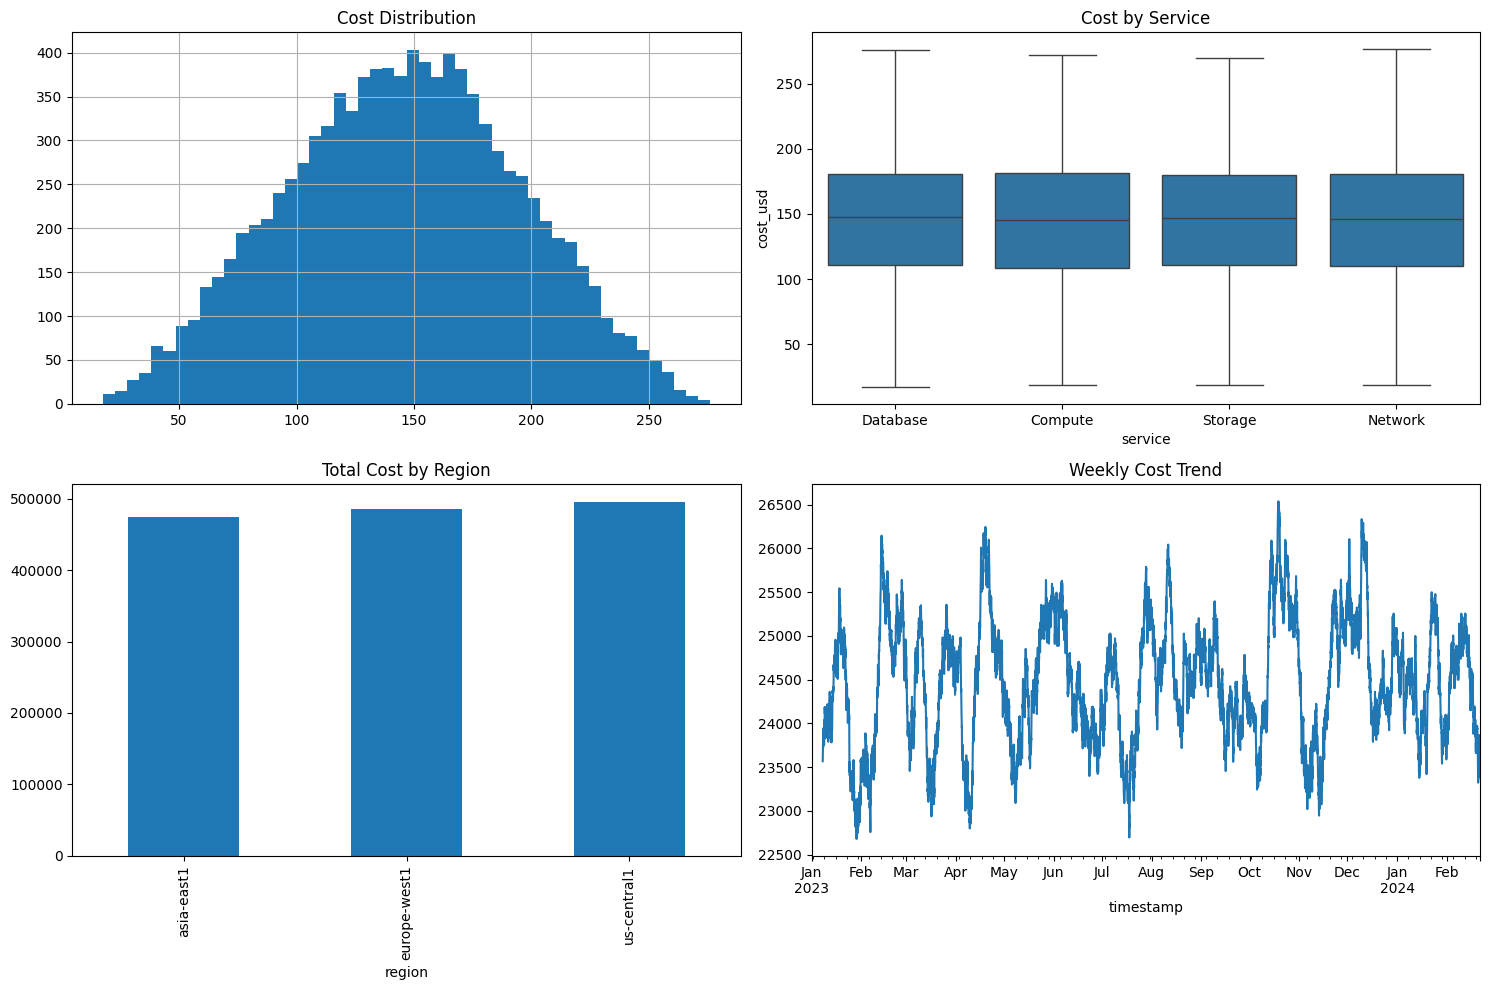


💡 KEY INSIGHTS:
Avg Monthly Cost: $104843.79
Most Expensive Service: Compute


In [3]:
# Quick EDA
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
df['cost_usd'].hist(bins=50)
plt.title('Cost Distribution')

plt.subplot(2,2,2)
sns.boxplot(data=df, x='service', y='cost_usd')
plt.title('Cost by Service')

plt.subplot(2,2,3)
df.groupby('region')['cost_usd'].sum().plot(kind='bar')
plt.title('Total Cost by Region')

plt.subplot(2,2,4)
df.set_index('timestamp')['cost_usd'].rolling(24*7).sum().plot()
plt.title('Weekly Cost Trend')

plt.tight_layout()
plt.show()

# Key insights
print("\n💡 KEY INSIGHTS:")
print(f"Avg Monthly Cost: ${df['cost_usd'].mean()*24*30:.2f}")
print(f"Most Expensive Service: {df.groupby('service')['cost_usd'].sum().idxmax()}")

In [4]:
# Feature engineering
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Encode categoricals
df_encoded = pd.get_dummies(df, columns=['region', 'service'], drop_first=True)

features = ['vm_count', 'storage_gb', 'network_gb', 'cpu_utilization',
           'hour', 'day_of_week', 'month', 'cost_per_vm']
X = df_encoded[features]
y = df_encoded['cost_usd']

# Train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"✅ Model MAE: ${mae:.2f}")

# Save model
joblib.dump(model, 'cost_predictor.pkl')
joblib.dump(features, 'features.pkl')
print("💾 Model saved!")

✅ Model MAE: $10.60
💾 Model saved!


In [5]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

# Load model
model = joblib.load('cost_predictor.pkl')
features = joblib.load('features.pkl')

app = FastAPI(title="Cloud Cost Predictor API")

class CostRequest(BaseModel):
    vm_count: float
    storage_gb: float
    network_gb: float
    cpu_utilization: float
    hour: int
    day_of_week: int
    month: int
    cost_per_vm: float

@app.post("/predict")
def predict_cost(request: CostRequest):
    data = [[request.vm_count, request.storage_gb, request.network_gb,
             request.cpu_utilization, request.hour, request.day_of_week,
             request.month, request.cost_per_vm]]
    prediction = model.predict(data)[0]
    return {"predicted_cost_usd": round(prediction, 2)}

# Test the API
test_data = {
    "vm_count": 25, "storage_gb": 2000, "network_gb": 500,
    "cpu_utilization": 0.7, "hour": 14, "day_of_week": 1,
    "month": 6, "cost_per_vm": 2.5
}

print("🧪 Test Prediction:", test_data)
# result = predict_cost(CostRequest(**test_data))
# print(result)

🧪 Test Prediction: {'vm_count': 25, 'storage_gb': 2000, 'network_gb': 500, 'cpu_utilization': 0.7, 'hour': 14, 'day_of_week': 1, 'month': 6, 'cost_per_vm': 2.5}


In [6]:
# ===== DEPLOYMENT SCRIPTS =====

# 1. Save FastAPI app
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np
import os

app = FastAPI()

model = joblib.load("cost_predictor.pkl")
features = joblib.load("features.pkl")

class CostRequest(BaseModel):
    vm_count: float
    storage_gb: float
    network_gb: float
    cpu_utilization: float
    hour: int
    day_of_week: int
    month: int
    cost_per_vm: float

@app.get("/")
def root():
    return {"message": "Cloud Cost Predictor API"}

@app.post("/predict")
def predict_cost(request: CostRequest):
    data = [[request.vm_count, request.storage_gb, request.network_gb,
             request.cpu_utilization, request.hour, request.day_of_week,
             request.month, request.cost_per_vm]]
    prediction = model.predict(data)[0]
    return {"predicted_cost_usd": float(prediction)}

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8080)
'''

with open('main.py', 'w') as f:
    f.write(api_code)

# 2. Create requirements.txt
reqs = '''fastapi==0.104.1
uvicorn==0.24.0
scikit-learn==1.3.2
joblib==1.3.2
pydantic==2.5.0
numpy==1.24.3
gunicorn==21.2.0
'''

with open('requirements.txt', 'w') as f:
    f.write(reqs)

# 3. Save model files
joblib.dump(model, 'cost_predictor.pkl')
joblib.dump(features, 'features.pkl')

print("✅ Deployment files ready!")


✅ Deployment files ready!
